In [3]:
import sys
sys.path.append("/content")

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from _Adaline import Adaline
data = pd.read_csv("mess_dataset_5000.csv")
X = data.drop(columns=["student_id","mess_duration"]).values
y = data["mess_duration"].values
X = (X - X.mean(axis=0)) / X.std(axis=0)#centered

Since the dataset contains multiple features, direct visualization in the original feature space is not possible.
Therefore, Principal Component Analysis (PCA) was implemented manually to project the dataset onto the
first two principal components.
The feature matrix was first centered and the covariance matrix was computed. Eigen-decomposition of
the covariance matrix produced eigenvectors corresponding to directions of maximum variance. The dataset
was then projected onto the two eigenvectors with the largest eigenvalues.


Figure shows the resulting two-dimensional projection of the dataset. Each point corresponds to a
student-meal instance and is colored according to the mess duration value.
The projection reveals two major clusters along the first principal component (PC1). This indicates that
some combinations of features, such as meal time or lifestyle patterns, contribute significantly to the variance
in the dataset. However, the mess duration values vary within each cluster, suggesting that multiple factors
influence the target variable.

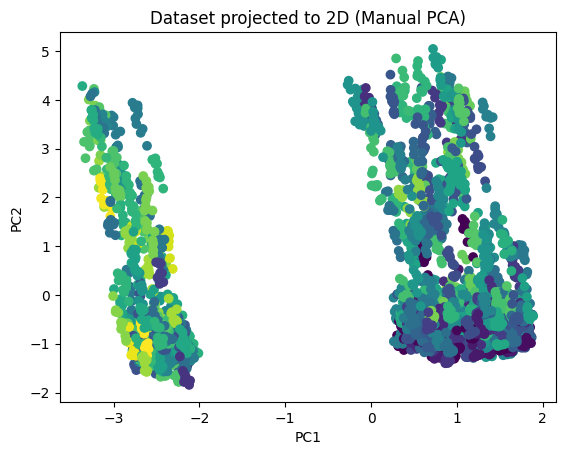

In [5]:
X_centered = X - np.mean(X, axis=0)
cov_matrix = np.dot(X_centered.T, X_centered) / X.shape[0]
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort by descending eigenvalues
idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]

# Take first 2 components
W = eigenvectors[:, :2]
X_2d = np.dot(X_centered, W)
import matplotlib.pyplot as plt

plt.scatter(X_2d[:,0], X_2d[:,1], c=y, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Dataset projected to 2D (Manual PCA)")
plt.show()

The ADALINE model was trained using batch gradient descent to minimize the Mean Squared Error (MSE).
The dataset was divided into training (80%) and validation (20%) sets. During training, both training and
validation errors were recorded across epochs

In [6]:
np.random.seed(42)
indices = np.random.permutation(len(X))

split = int(0.8 * len(X))

train_idx = indices[:split]
val_idx = indices[split:]

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

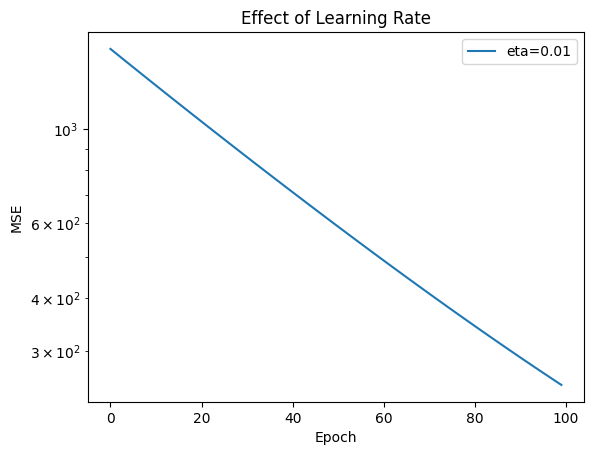

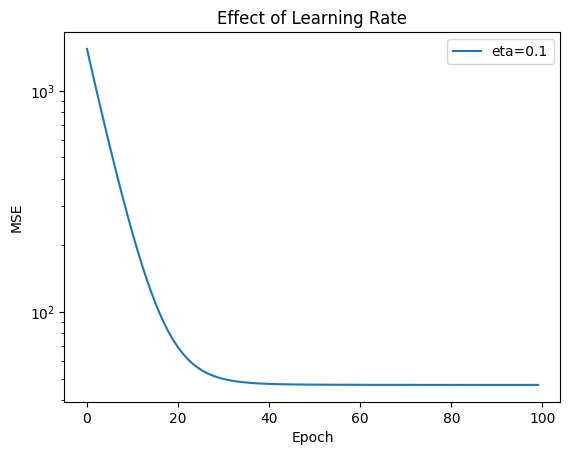

Diverged.


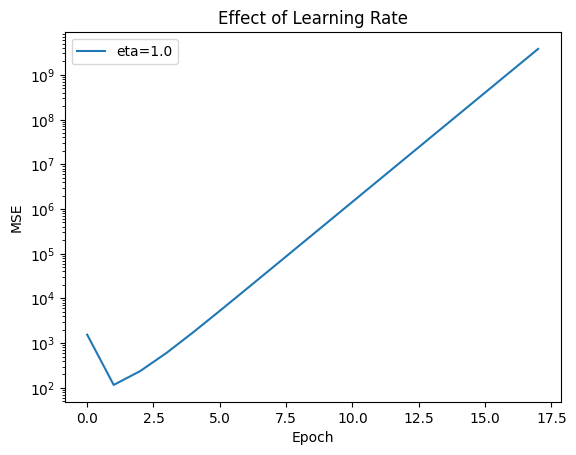

Diverged.


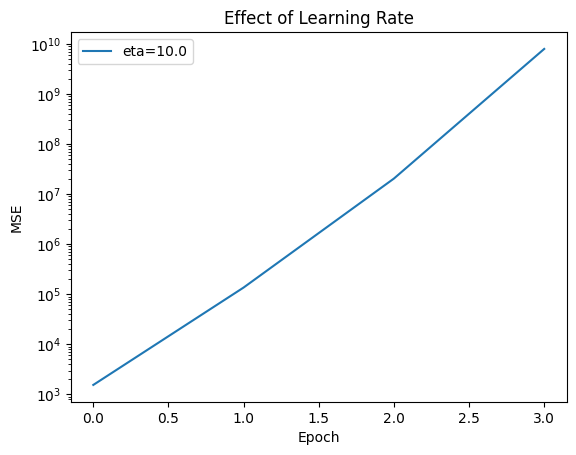

In [7]:
etas = [0.01, 0.1, 1.0, 10.0]

for eta in etas:
    model = Adaline(learning_rate=eta, max_iterations=100)
    train_hist, _ = model.fit(X_train, y_train,X_val,y_val)
    plt.plot(train_hist, label=f"eta={eta}")
    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()
    plt.title("Effect of Learning Rate")
    plt.show()

Effect of Learning Rate
To study the effect of the learning rate on convergence, ADALINE was trained with learning rates:
η ∈ {0.01, 0.1, 1.0, 10.0}
The Mean Squared Error was plotted against training epochs for each learning rate.

• η = 0.01: Convergence is slow but stable.

• η = 0.1: Fast and stable convergence, producing the best results.

• η = 1.0: The model becomes unstable and the error begins to increase.

• η = 10.0: The algorithm diverges quickly due to excessively large updates.

These results demonstrate the importance of selecting an appropriate learning rate for gradient-based
optimization.

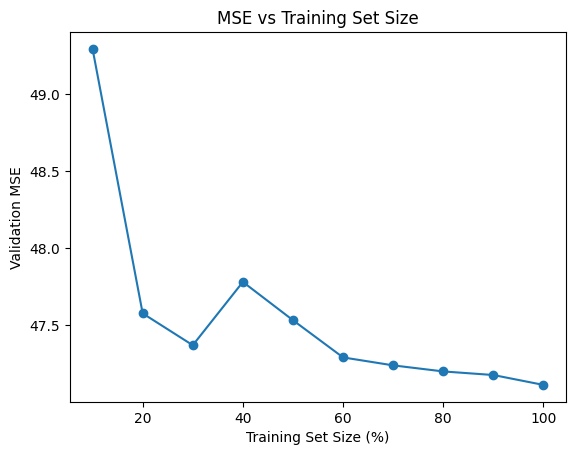

In [8]:
sizes = np.arange(0.1, 1.1, 0.1)
mses = []
np.random.seed(42)

for size in sizes:

    subset_size = int(size * len(X_train))

    X_small = X_train[:subset_size]
    y_small = y_train[:subset_size]

    model = Adaline(learning_rate=0.1, max_iterations=100)
    model.fit(X_small, y_small)

    mse = model.score(X_val, y_val)
    mses.append(mse)
plt.plot(sizes*100, mses, marker='o')
plt.xlabel("Training Set Size (%)")
plt.ylabel("Validation MSE")
plt.title("MSE vs Training Set Size")
plt.show()

Effect of Training Set Size

To analyze how the amount of training data affects performance, the size of the training set was varied
from 10% to 100% in increments of 10%. For each training size, the ADALINE model was trained and MSE was evaluated on the validation set.
Above figure shows the relationship between training set size and validation MSE.

This plot demonstrates that the ADALINE model reaches a performance plateau once approximately 60% of the training data is utilized.
From this, we can conclude that the model has successfully captured the dominant linear relationships within the dataset. Since ADALINE is a linear learner minimizing the sum of squared errors, the flattening of the curve indicates that additional data points are providing redundant information. The model has converged toward the global least-squares solution, and further increasing the training set size yields only marginal improvements in validation accuracy. This suggests that the remaining error is likely due to inherent noise in the data or the limitations of a linear decision boundary (model bias).